<>:50: SyntaxWarning: invalid escape sequence '\V'
<>:50: SyntaxWarning: invalid escape sequence '\V'
/tmp/ipykernel_26929/2708341422.py:50: SyntaxWarning: invalid escape sequence '\V'
  plt.semilogy(ts, np.exp(-2)*np.array(norms), '-', label='$e^{-2}\Vert U(t) \Vert^2$')


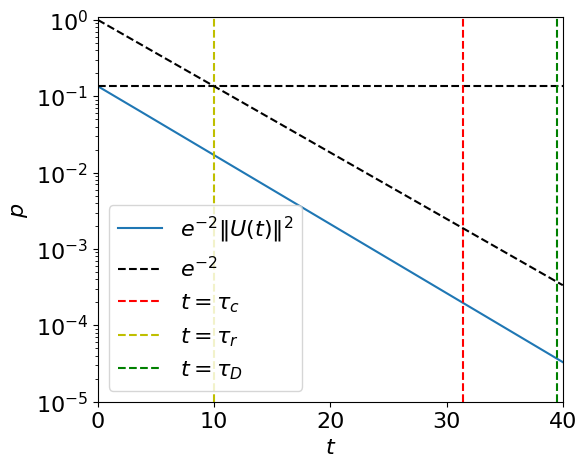

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm
from lchs import spectral_diff_adv, spectral_diff_adv_op

n_qubits = 4

D = 1
N = 2**n_qubits
L = 2 * np.pi               
time = 40  
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_L = 0.0
c_H = 0.2
#c = c_H*np.ones_like(x)
c = -4*(c_H -c_L)/L**2 *x**2 + 4*(c_H -c_L)/L *x 
#cx = np.zeros_like(x)
cx = -8*(c_H - c_L)/L**2 *x + 4*(c_H -c_L)/L 

a = 0.1
a_x = a*np.ones_like(x)

# Initial State: Gaussian centered in the middle
sigma = L/20
state = np.exp(-0.5*((x-dx*N/4)/sigma)**2)
state = state / np.linalg.norm(state)

ts = np.linspace(0, time, 1000)

plt.rcParams.update({
    "font.size": 16,
    "figure.figsize": (6, 5), 
    "axes.labelsize": 16,       
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})
plt.figure()
norms = []

for t in ts:
    U = spectral_diff_adv_op(n_qubits, t, cx, c, D, L, a_x, -a)
    norm = np.linalg.norm(U,2)**2
    norms.append(norm)
plt.semilogy(ts, np.exp(-2)*np.array(norms), '-', label='$e^{-2}\Vert U(t) \Vert^2$')

plt.axhline(np.exp(-2), color='k', linestyle='--', label=r'$e^{-2}$')
Tau_c = L/c_H
Tau_r = 1/a
Tau_D = L**2 / D
plt.axvline(Tau_c, color='r', linestyle='--', label=r'$t=\tau_c$')
plt.axvline(Tau_r, color='y', linestyle='--', label=r'$t=\tau_r$')
plt.axvline(Tau_D, color='g', linestyle='--', label=r'$t=\tau_D$')
plt.xlabel('$t$')
plt.ylabel('$p$')
plt.legend()
plt.ylim(1e-5,1e0+0.1)
plt.xlim(0, time)
plt.plot(ts, np.exp(-2*a*ts), 'k--', label=r'$e^{-2at}$')

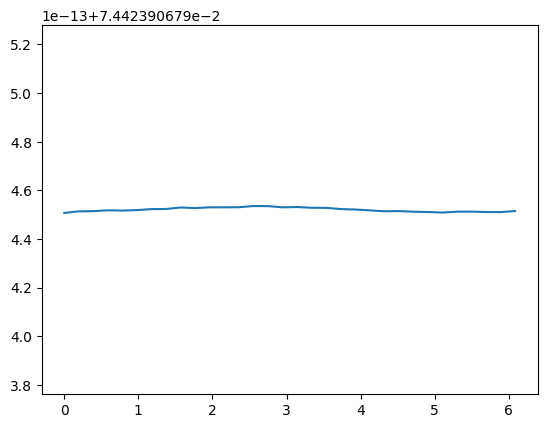

In [11]:
spectral = U@state
plt.plot(x, spectral, label='Final State')